# График зависимости min(GOF_VR, GOF_AFT) -> Exhumed_thickness

In [91]:
from typing import Literal
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from scipy.interpolate import griddata

import pathlib

In [92]:
def drag_fig(
    filepath: str,
    figtype: Literal["min_gof", "max_gof", "mean_gof"] = "min_gof",
    min_gof: float = 0.6,
    min_heatflow=0,
    max_heatflow: float = 75.0,
    save_path: str = "./fig.png",
    contours_levels=[0.5, 0.6, 0.7],
):
    assert pathlib.Path(
        filepath
    ).exists(), f"Указанный файл не найден: {filepath}"

    # 1. Загрузка данных
    df = pd.read_csv(filepath, skipinitialspace=True)
    df.columns = df.columns.str.strip()

    # 2. Извлечение данных
    x_raw = df["exhumed_thicknesses_0"].values  # эрозия, м

    # Парсинг теплового потока
    y_raw = np.array(
        [
            float(hf_str.strip("[]").split()[0]) * 1000
            for hf_str in df["heatflow_history"]
        ]
    )

    # Целевая переменная: min(GOF_VR, GOF_AFT)
    z_raw = (
        (np.minimum(df["vr_gof"].values, df["aft_age_gof"].values))
        if figtype == "min_gof"
        else (
            (np.maximum(df["vr_gof"].values, df["aft_age_gof"].values))
            if figtype == "max_gof"
            else np.mean(
                [df["vr_gof"].values, df["aft_age_gof"].values], axis=0
            )
            # (
            #     (np.minimum(df["vr_gof"].values, df["aft_age_gof"].values))
            #     + (np.maximum(df["vr_gof"].values, df["aft_age_gof"].values))
            # )
            # / 2
        )
    )

    # 3. Уникальные значения
    x_unique = np.sort(
        df["exhumed_thicknesses_0"].unique()
    )  # [500, 750, 1000, 1250]
    y_unique = np.sort(np.unique(y_raw))  # [68, 70, ..., 82]

    # 4. Создание плотной сетки, покрывающей ВСЮ область данных
    X, Y = np.meshgrid(
        np.linspace(x_unique.min(), x_unique.max(), 200),
        np.linspace(y_unique.min(), y_unique.max(), 200),
    )

    # 5. Интерполяция
    Z = griddata(
        points=(x_raw, y_raw), values=z_raw, xi=(X, Y), method="linear"
    )

    # 6. Уровни цвета от 0.0 до 1.0 с шагом
    levels = np.arange(0.0, 1.01, 0.2)

    # 7. Построение
    plt.figure(figsize=(12, 8))
    contourf = plt.contourf(
        X, Y, Z, levels=levels, cmap="viridis", extend="both"
    )

    # Красные изолинии (опционально)
    contours = plt.contour(
        X, Y, Z, levels=contours_levels, colors="red", linewidths=1.2
    )
    plt.clabel(contours, fmt="%.2f", fontsize=9)

    # Выделение областей с целевым диапазоном GOF и Heatflow
    mask = (Z >= min_gof) & (Y <= max_heatflow) & (Y >= min_heatflow)
    # Вариант 1: закрасить область
    plt.contourf(
        X,
        Y,
        mask,
        levels=[0.5, 1],
        colors=["none", "green"],
        alpha=0.1,
        hatches=["///"],
    )

    # Вариант 2: только контур границы
    # plt.contour(
    #     X, Y, mask.astype(int), levels=[0.5], colors="green", linewidths=2
    # )

    # Серые пунктирные линии по значениям эрозии
    for th in x_unique:
        plt.axvline(
            x=th, color="gray", linestyle=":", linewidth=1.5, alpha=0.8
        )

    # Оформление
    plt.xlabel("Суммарная мощность эксгумации (м)", fontsize=12)
    plt.ylabel("Тепловой поток (мВт м$^{-2}$)", fontsize=12)
    # plt.title("Скважина KDK-01", loc="left", fontweight="bold", fontsize=14)
    plt.colorbar(
        contourf,
        ticks=levels,
        label=(
            ("мин" if figtype == "min_gof" else "макс")
            + "(К$_{согл.VR}$, К$_{согл.AFT}$)"
        ),
    )

    # 🔥 Заполняем ВСЮ область данными:
    plt.xlim(x_unique.min(), x_unique.max())
    plt.ylim(y_unique.min(), y_unique.max())

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

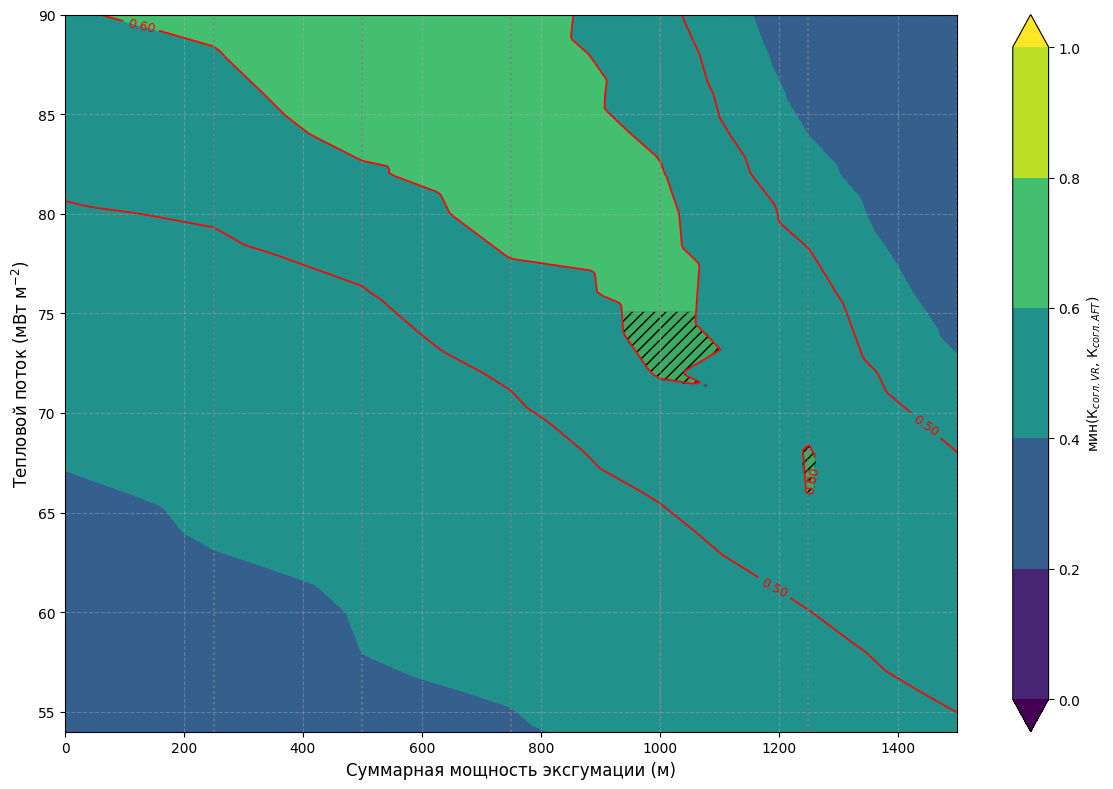

In [93]:
# Результаты расчетов с исключенными аномальными зернами AFT в KDK-01
drag_fig(
    "../model_output/without_anomalies/publishable_results/model_results_2-2-2026_KDK-01_ms0-133_final.csv",
    "min_gof",
    save_path="./without_anomalies.png",
)

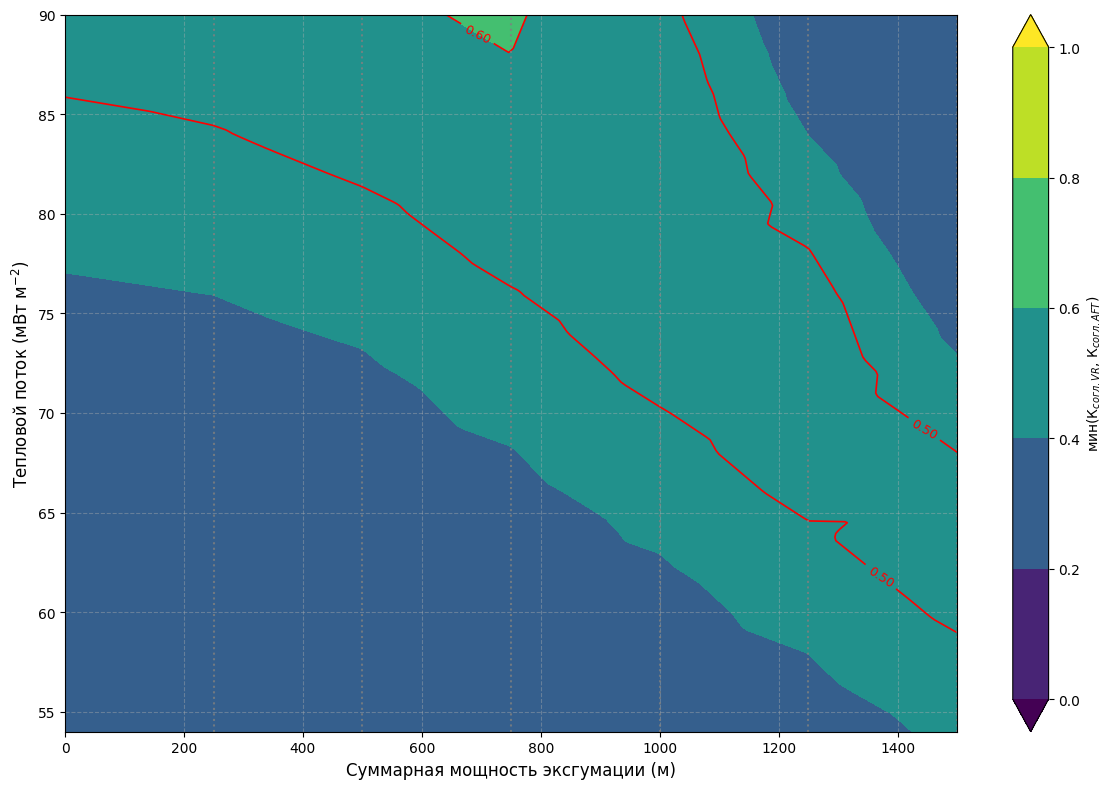

In [94]:
# Результаты расчетов с аномальными зернами AFT в KDK-01
drag_fig(
    "../model_output/with_anomalies/publishable_results/model_results_2-2-2026_KDK-01_ms0-133_final.csv",
    "min_gof",
    save_path="./with_anomalies.png",
)

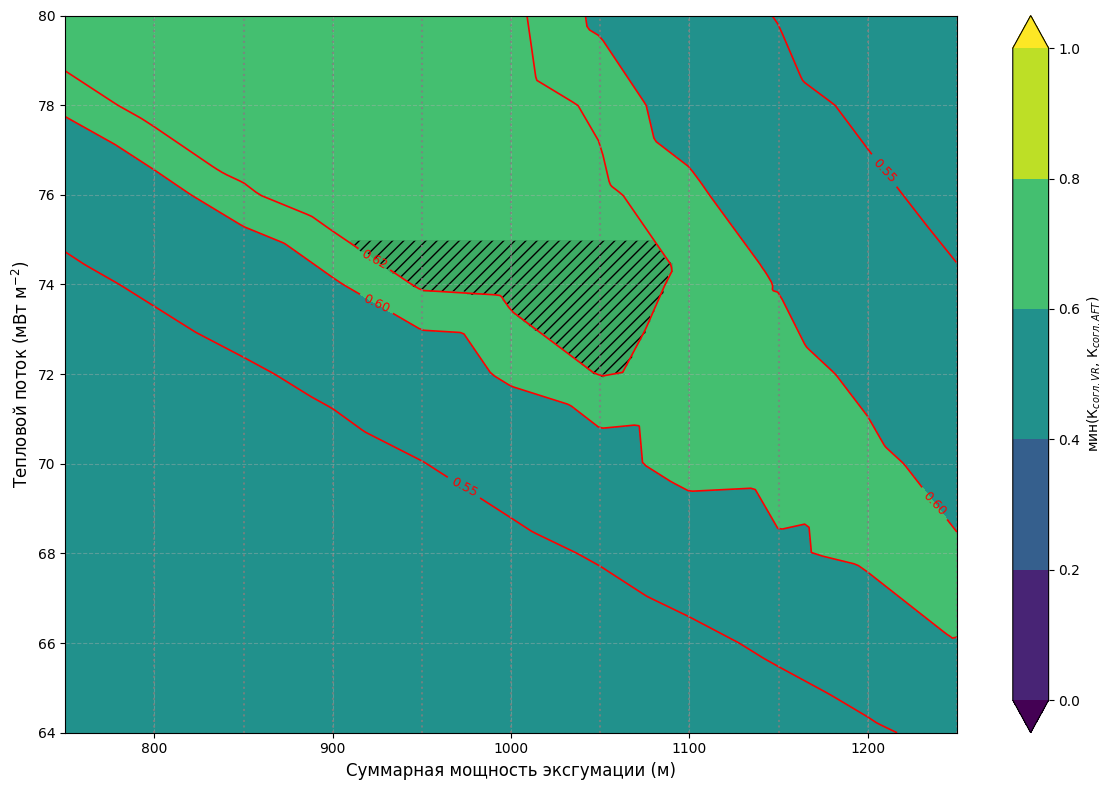

In [108]:
# Результаты детализированных расчетов в таргетированной области
drag_fig(
    "../model_output/target_area/model_results_5-2-2026_KDK-01_ms0-99_final.csv",
    "min_gof",
    save_path="./target_area.png",
    contours_levels=[0.55, 0.6, 0.6155],
    min_gof=0.6155,
    min_heatflow=70,
    max_heatflow=75,
)

In [ ]:
df = pd.read_csv(
    "../model_output/target_area/model_results_5-2-2026_KDK-01_ms0-99_final.csv",
    skipinitialspace=True,
)
df.columns = df.columns.str.strip()

max_min_gof = np.minimum(df["vr_gof"].values, df["aft_age_gof"].values)
max_min_gof

array([0.43041867, 0.44345543, 0.46286544, 0.48665216, 0.51037617,
       0.53838567, 0.57029277, 0.60434764, 0.63350648, 0.43526356,
       0.45375328, 0.47455462, 0.49987457, 0.5268748 , 0.55746331,
       0.59105992, 0.62329171, 0.6376978 , 0.44356753, 0.46534535,
       0.48811894, 0.51535061, 0.54385244, 0.57654862, 0.6128661 ,
       0.63231766, 0.63207373, 0.45397668, 0.47829718, 0.50346083,
       0.53173624, 0.56145255, 0.59767251, 0.62765909, 0.6277788 ,
       0.62942276, 0.4664701 , 0.49222298, 0.51892968, 0.54891093,
       0.58288565, 0.61780942, 0.62377684, 0.62539589, 0.62742108,
       0.47971054, 0.507186  , 0.53750983, 0.56906388, 0.6048463 ,
       0.61991222, 0.62142537, 0.6231122 , 0.61971643, 0.49583366,
       0.52393223, 0.55434682, 0.58951194, 0.61611408, 0.6174784 ,
       0.61888432, 0.61294037, 0.5960571 , 0.51156629, 0.54015213,
       0.57391694, 0.61158837, 0.61356168, 0.61475909, 0.60542348,
       0.587786  , 0.57107426, 0.52812409, 0.55782732, 0.59653

In [121]:
idx = np.argmax(max_min_gof)
max_min_gof[idx]

np.float64(0.6376978033599979)